In [166]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [167]:
data = pd.read_csv('/kaggle/input/placement-prediction-dataset/placementdata.csv')
print("Data Loaded Successfully!")
data.head()

Data Loaded Successfully!


,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


In [168]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  object 
 8   PlacementTraining          10000 non-null  object 
 9   SSC_Marks                  10000 non-null  int64  
 10  HSC_Marks                  10000 non-null  int64  
 11  PlacementStatus            10000 non-null  object 
dtypes: float64(2), int64(7), object(3)
memory usage: 937.6+ KB


# EDA

In [169]:
# Frequency distribution for categorical columns
print("Extracurricular Activities Distribution:")
print(data['ExtracurricularActivities'].value_counts())

print("\nPlacement Training Distribution:")
print(data['PlacementTraining'].value_counts())

print("\nPlacement Status Distribution:")
print(data['PlacementStatus'].value_counts())

for col in ['ExtracurricularActivities', 'PlacementTraining', 'PlacementStatus']:
    print(f"\n{col} Distribution:")
    print(data[col].value_counts())


Extracurricular Activities Distribution:
ExtracurricularActivities
Yes    5854
No     4146
Name: count, dtype: int64

Placement Training Distribution:
PlacementTraining
Yes    7318
No     2682
Name: count, dtype: int64

Placement Status Distribution:
PlacementStatus
NotPlaced    5803
Placed       4197
Name: count, dtype: int64

ExtracurricularActivities Distribution:
ExtracurricularActivities
Yes    5854
No     4146
Name: count, dtype: int64

PlacementTraining Distribution:
PlacementTraining
Yes    7318
No     2682
Name: count, dtype: int64

PlacementStatus Distribution:
PlacementStatus
NotPlaced    5803
Placed       4197
Name: count, dtype: int64


In [170]:
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = data.select_dtypes(include=['object']).columns
print(f"\nNumerical Columns: {numerical_cols}")
print(f"Categorical Columns: {categorical_cols}")



Numerical Columns: Index(['StudentID', 'CGPA', 'Internships', 'Projects',
       'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating',
       'SSC_Marks', 'HSC_Marks'],
      dtype='object')
Categorical Columns: Index(['ExtracurricularActivities', 'PlacementTraining', 'PlacementStatus'], dtype='object')


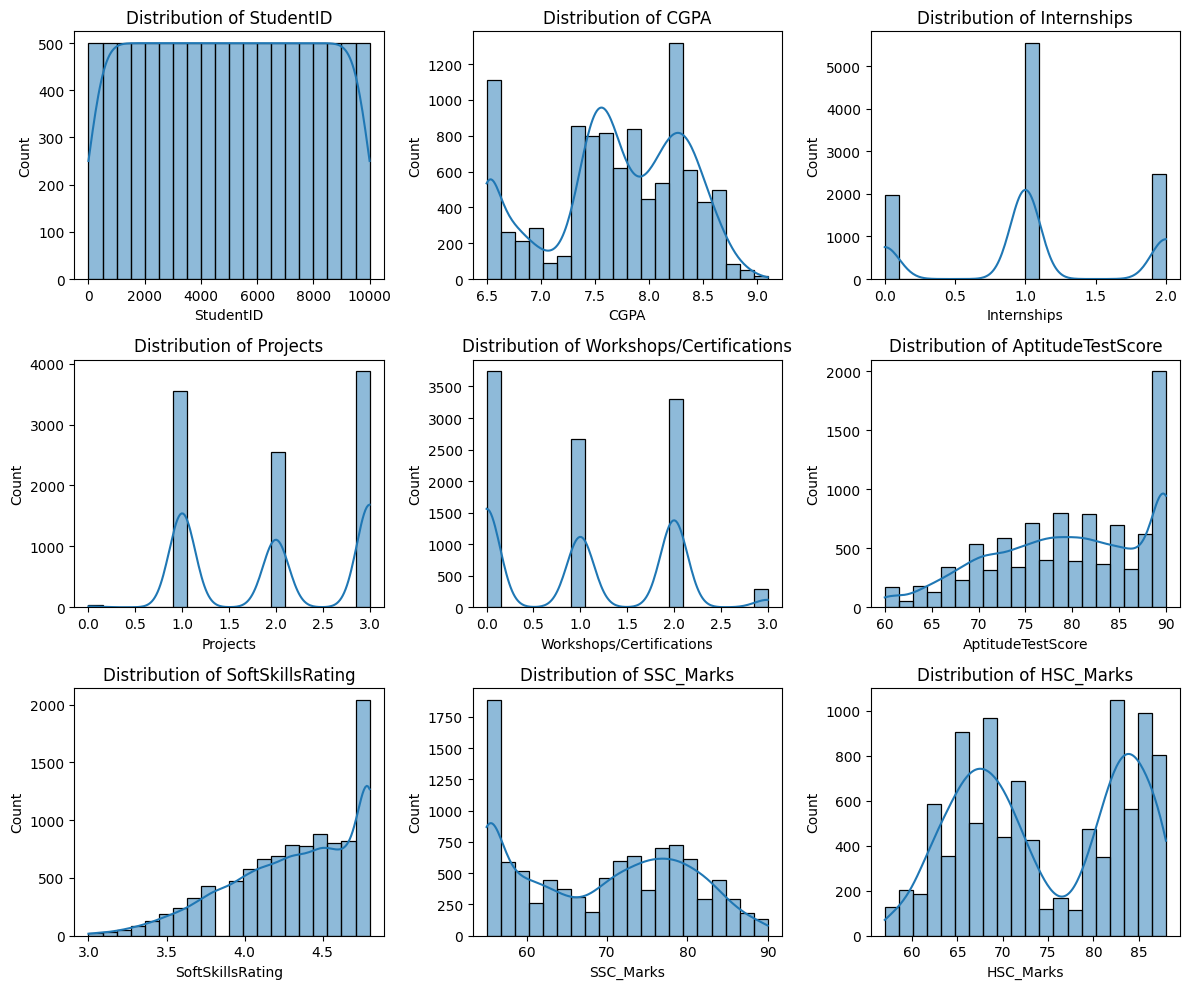

In [171]:
plt.figure(figsize=(12, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(data[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


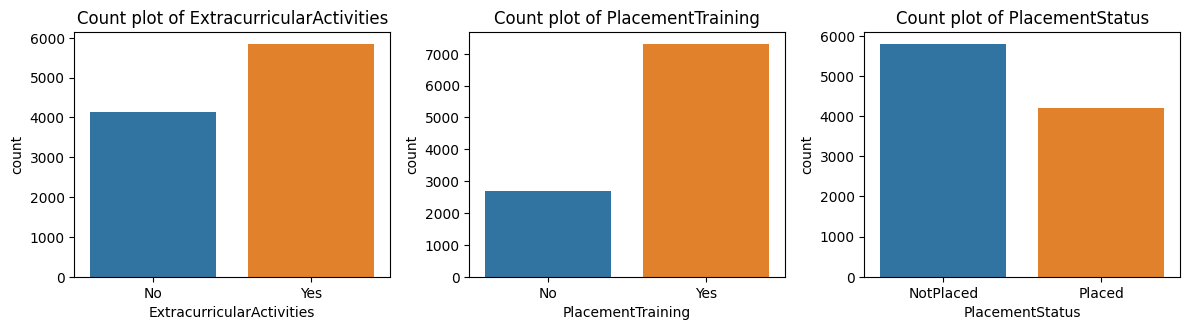

In [172]:
plt.figure(figsize=(12, 6))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 3, i)
    sns.countplot(x=data[col])
    plt.title(f'Count plot of {col}')
plt.tight_layout()
plt.show()

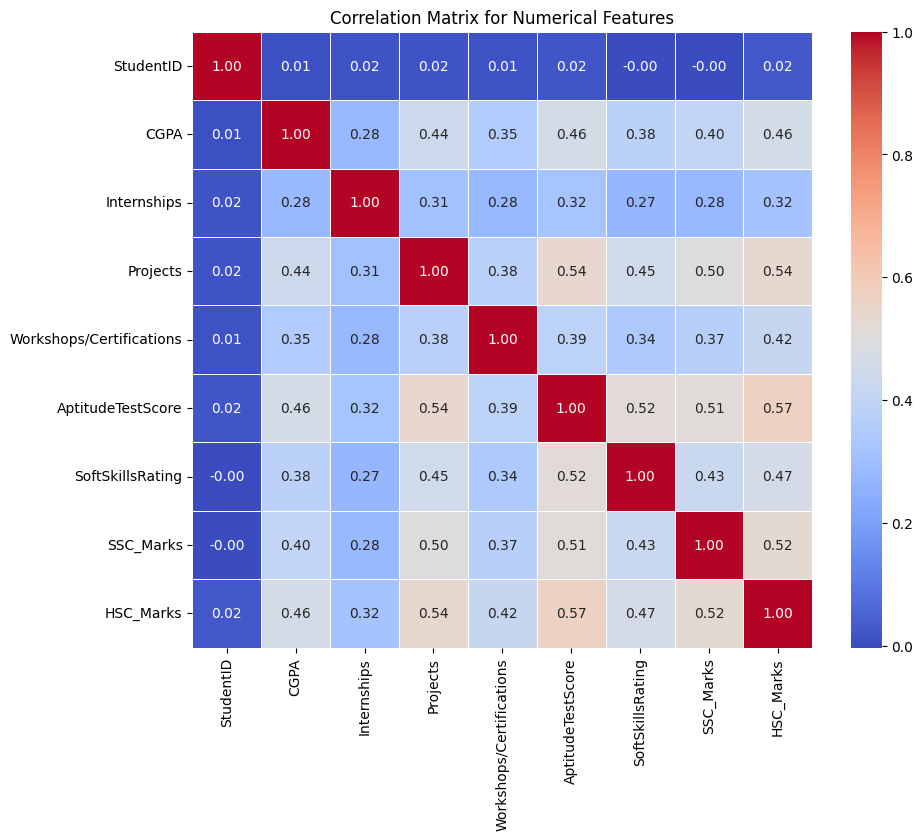

In [173]:
corr_matrix = data[numerical_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix for Numerical Features")
plt.show()

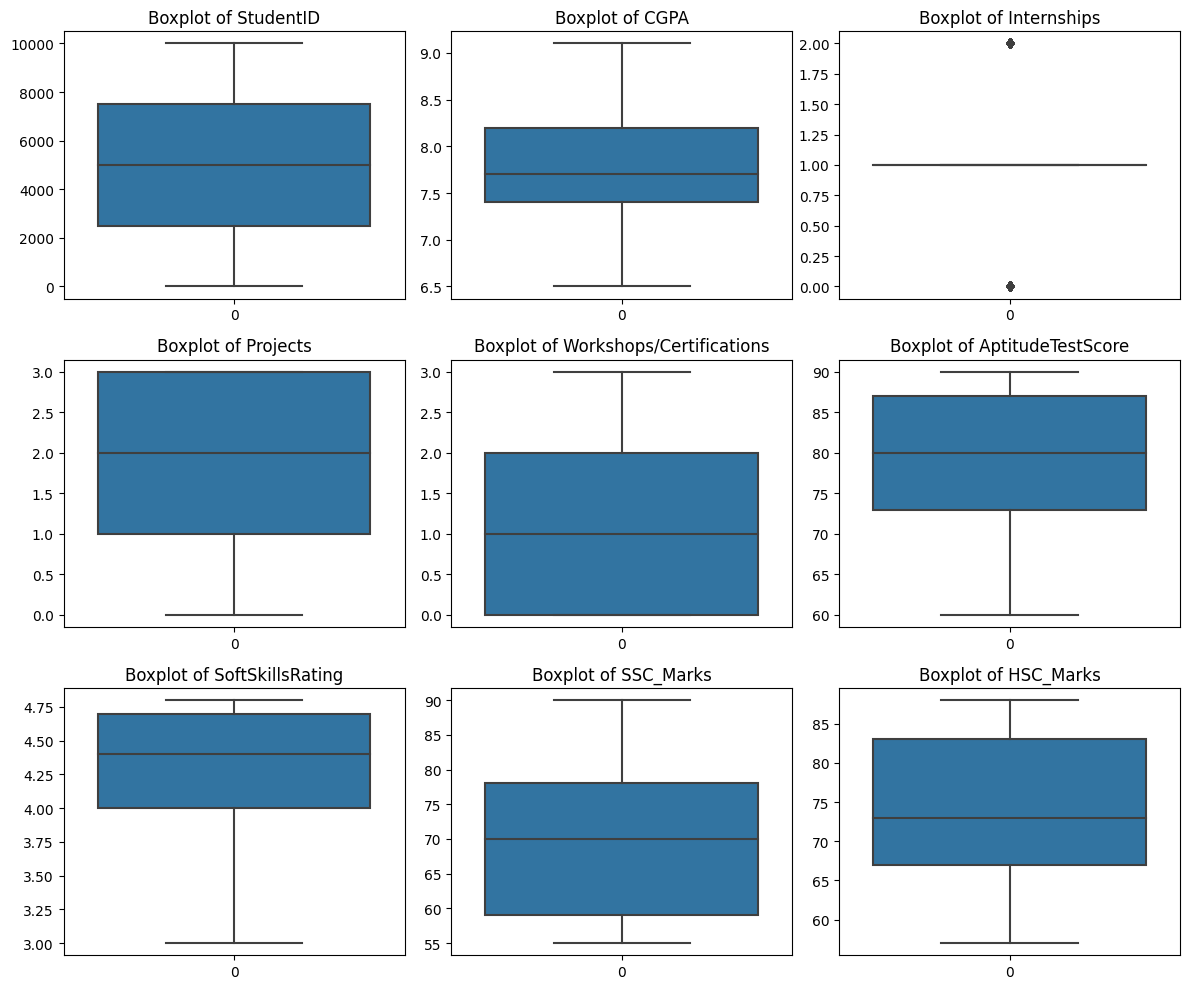

In [174]:
plt.figure(figsize=(12, 10))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=data[col])
    plt.title(f'Boxplot of {col}')
    
plt.tight_layout()
plt.show()

In [175]:
Q1 = data[numerical_cols].quantile(0.25)
Q3 = data[numerical_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((data[numerical_cols] < (Q1 - 1.5 * IQR)) | (data[numerical_cols] > (Q3 + 1.5 * IQR)))
outliers_count = outliers.sum()
print("\nOutliers count per numerical column:")
print(outliers_count)


Outliers count per numerical column:
StudentID                      0
CGPA                           0
Internships                 4458
Projects                       0
Workshops/Certifications       0
AptitudeTestScore              0
SoftSkillsRating               0
SSC_Marks                      0
HSC_Marks                      0
dtype: int64


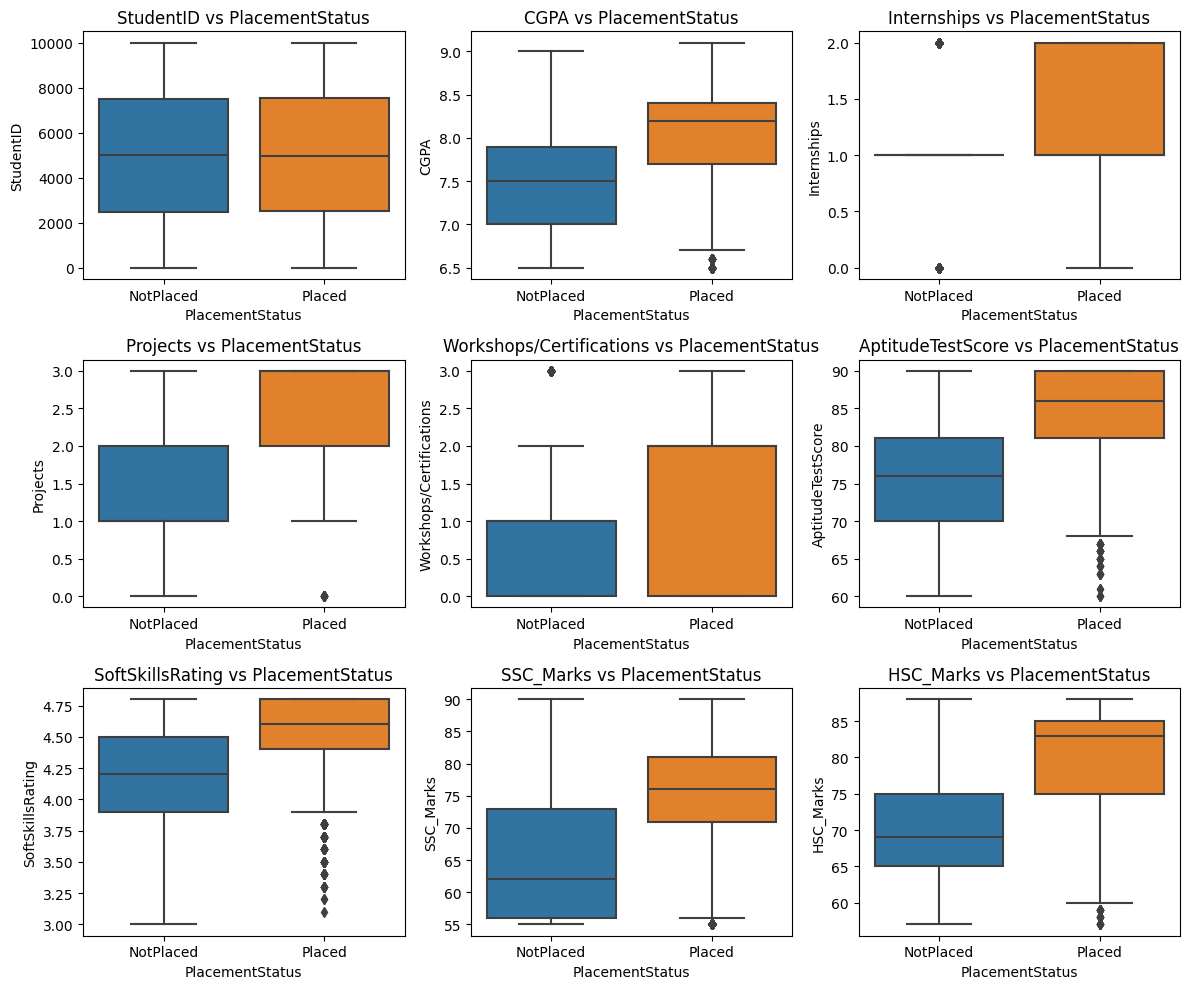

In [176]:
plt.figure(figsize=(12, 10))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=data['PlacementStatus'], y=data[col])
    plt.title(f'{col} vs PlacementStatus')

plt.tight_layout()
plt.show()

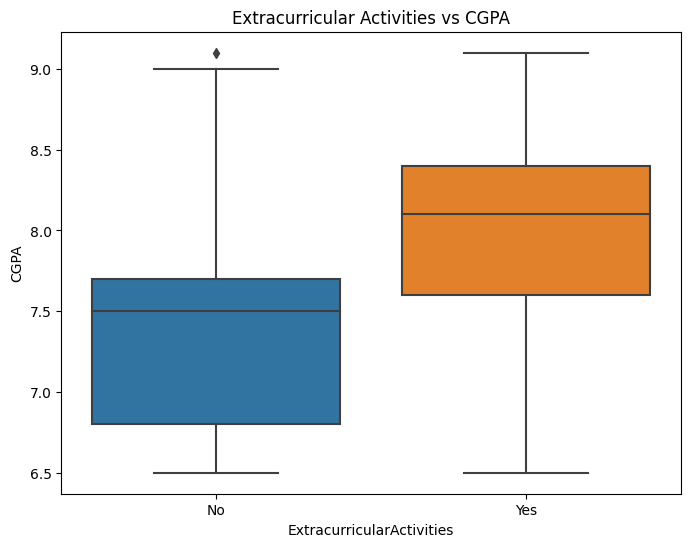

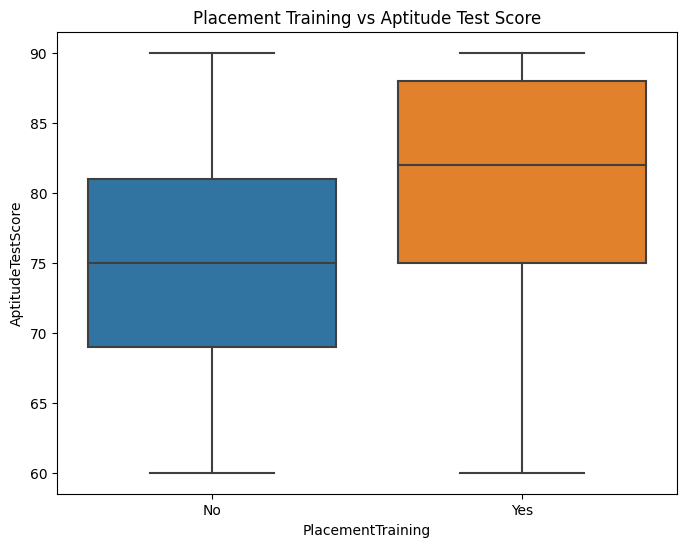

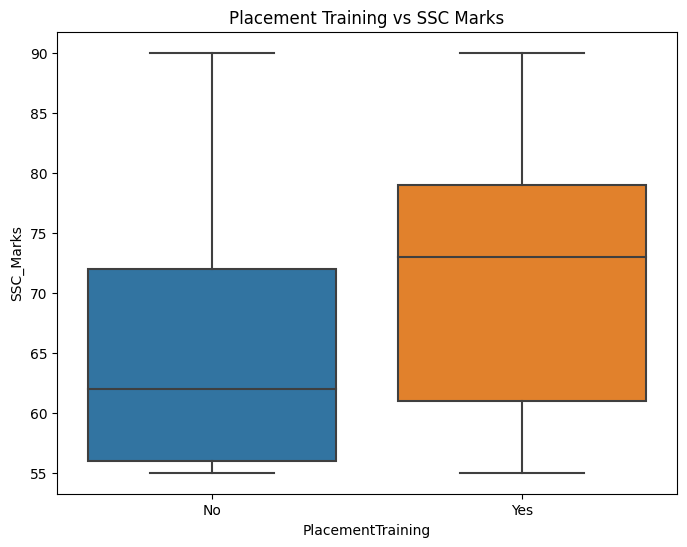

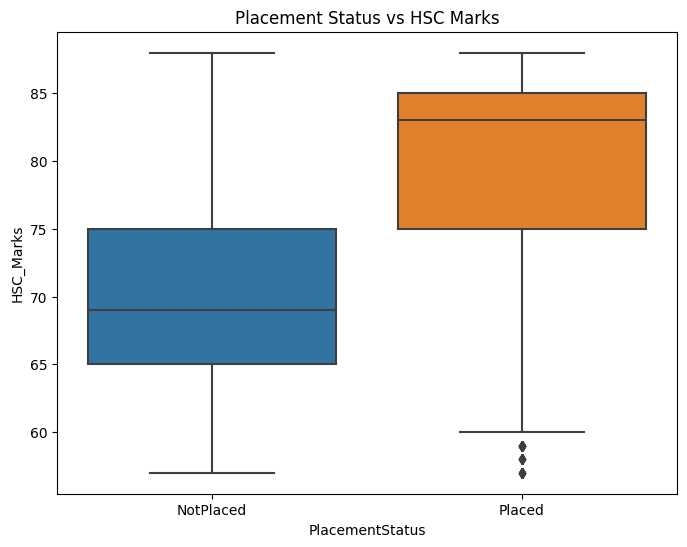

In [177]:
# Categorical vs Numerical: Boxplot for ExtracurricularActivities vs CGPA
plt.figure(figsize=(8, 6))
sns.boxplot(x=data['ExtracurricularActivities'], y=data['CGPA'])
plt.title('Extracurricular Activities vs CGPA')
plt.show()

# Categorical vs Numerical: Boxplot for PlacementTraining vs AptitudeTestScore
plt.figure(figsize=(8, 6))
sns.boxplot(x=data['PlacementTraining'], y=data['AptitudeTestScore'])
plt.title('Placement Training vs Aptitude Test Score')
plt.show()

# Categorical vs Numerical: Boxplot for PlacementTraining vs SSC Marks
plt.figure(figsize=(8, 6))
sns.boxplot(x=data['PlacementTraining'], y=data['SSC_Marks'])
plt.title('Placement Training vs SSC Marks')
plt.show()

# Categorical vs Numerical: Boxplot for PlacementStatus vs HSC Marks
plt.figure(figsize=(8, 6))
sns.boxplot(x=data['PlacementStatus'], y=data['HSC_Marks'])
plt.title('Placement Status vs HSC Marks')
plt.show()

# Visualization

In [178]:
! pip install umap-learn

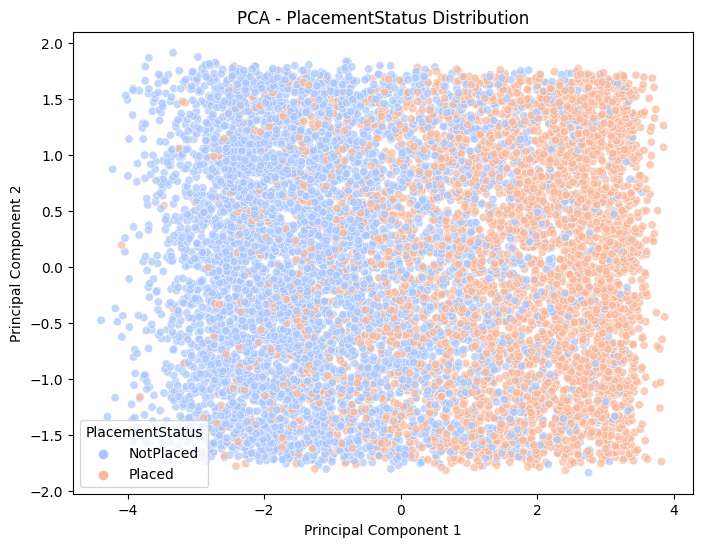

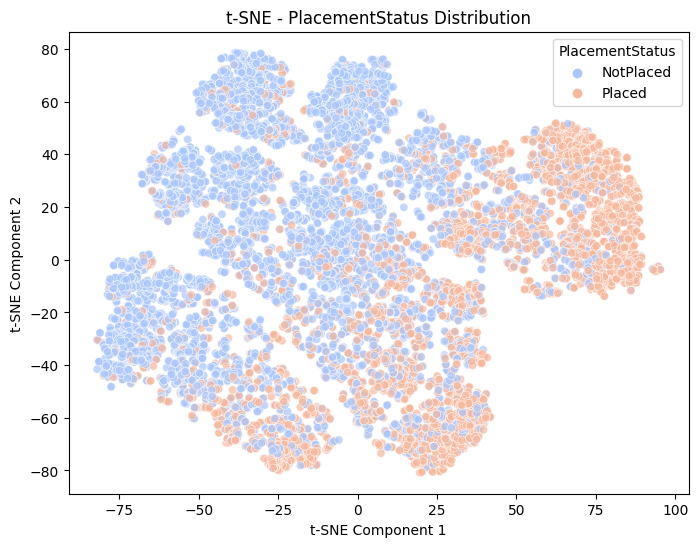

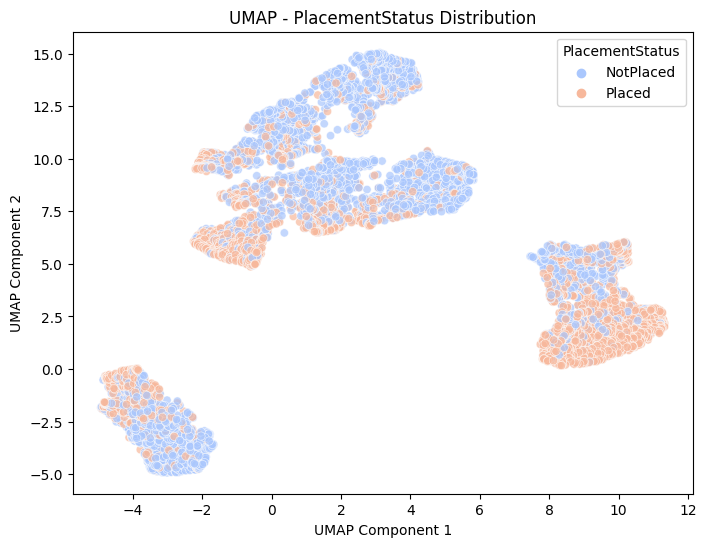

In [179]:
# Step 1: Import necessary libraries
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


# Step 2: Select numerical columns (excluding categorical features)
numerical_data = data[numerical_cols]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(numerical_data)

# Step 4: PCA - Reduce dimensions to 2D
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# Plotting PCA
plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=data['PlacementStatus'], palette='coolwarm', alpha=0.7)
plt.title('PCA - PlacementStatus Distribution')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

# Step 5: t-SNE - Reduce dimensions to 2D
tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(scaled_data)

# Plotting t-SNE
plt.figure(figsize=(8, 6))
sns.scatterplot(x=tsne_result[:, 0], y=tsne_result[:, 1], hue=data['PlacementStatus'], palette='coolwarm', alpha=0.7)
plt.title('t-SNE - PlacementStatus Distribution')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()

# Step 6: UMAP - Reduce dimensions to 2D
umap_model = umap.UMAP(n_components=2, random_state=42)
umap_result = umap_model.fit_transform(scaled_data)

# Plotting UMAP
plt.figure(figsize=(8, 6))
sns.scatterplot(x=umap_result[:, 0], y=umap_result[:, 1], hue=data['PlacementStatus'], palette='coolwarm', alpha=0.7)
plt.title('UMAP - PlacementStatus Distribution')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.show()


In [180]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

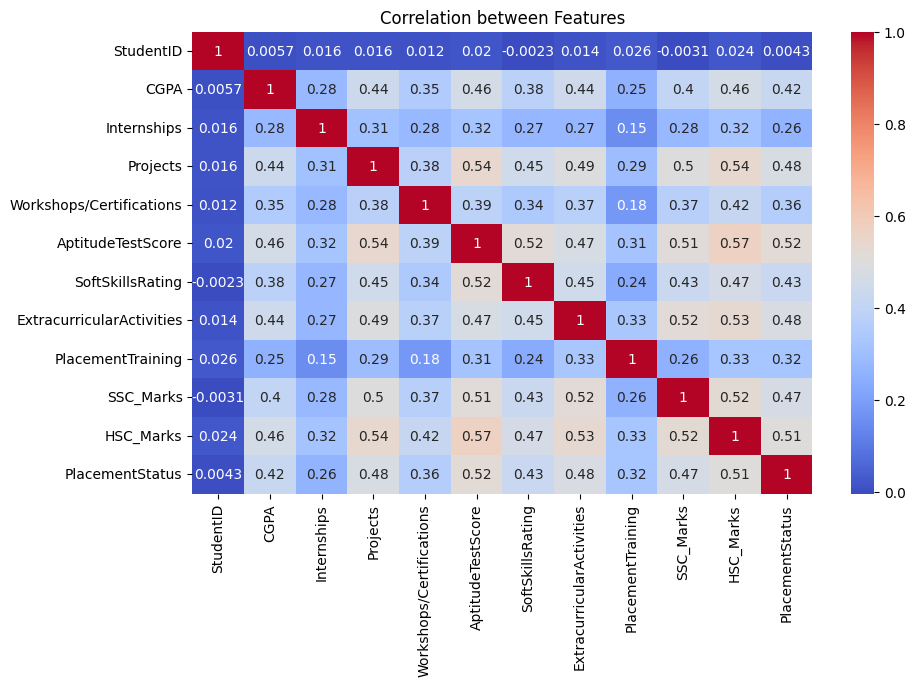

In [181]:
# Step 3: Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation between Features")
plt.show()


# Classification

<Figure size 1000x600 with 0 Axes>

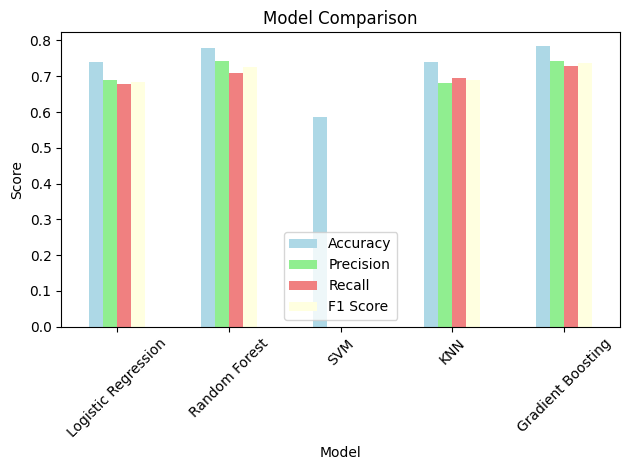

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.7410,0.690418,0.678744,0.684531
Random Forest,0.7780,0.743038,0.708937,0.725587
SVM,0.5860,0.000000,0.000000,0.000000
KNN,0.7395,0.682088,0.694444,0.688211
Gradient Boosting,0.7835,0.742927,0.729469,0.736137


In [182]:
# Step 1: Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Encode categorical variables (PlacementStatus)
encoder = LabelEncoder()
data['PlacementStatus'] = encoder.fit_transform(data['PlacementStatus'])

# Step 3: Select features and target variable
X = data[numerical_cols]  # Use only numerical columns
y = data['PlacementStatus']

# Step 4: Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Initialize classifiers
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Step 6: Train models and evaluate performance
model_results = {}
for model_name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict on the test set
    y_pred = model.predict(X_test)
    
    # Evaluate performance
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Store results
    model_results[model_name] = {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1 Score': f1}

# Step 7: Create a DataFrame for results
results_df = pd.DataFrame(model_results).T

# Step 8: Plot comparison of models
plt.figure(figsize=(10, 6))
results_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']].plot(kind='bar', color=['lightblue', 'lightgreen', 'lightcoral', 'lightyellow'])
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Display the results DataFrame
results_df


In [183]:
# Train a Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Get feature importance scores
feature_importance = rf_model.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': numerical_cols,
    'Importance': feature_importance
})

# Sort the features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display the most important features
print(feature_importance_df)

                    Feature  Importance
8                 HSC_Marks    0.192591
5         AptitudeTestScore    0.164109
0                 StudentID    0.128917
7                 SSC_Marks    0.125986
1                      CGPA    0.122088
6          SoftSkillsRating    0.089724
3                  Projects    0.084585
4  Workshops/Certifications    0.063352
2               Internships    0.028647


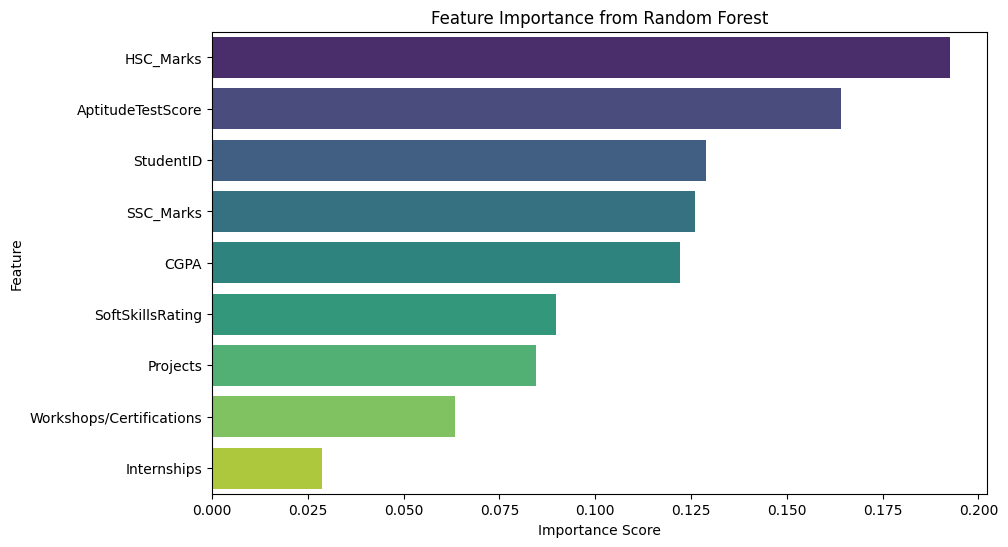

In [184]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance from Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()


In [185]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select top k features based on univariate tests
selector = SelectKBest(f_classif, k='all')
selector.fit(X, y)

# Get the scores for each feature
scores = selector.scores_

# Create a DataFrame for better visualization
feature_scores_df = pd.DataFrame({
    'Feature': numerical_cols,
    'Score': scores
})

# Sort the features by score
feature_scores_df = feature_scores_df.sort_values(by='Score', ascending=False)

# Display the features and their scores
print(feature_scores_df)


                    Feature        Score
5         AptitudeTestScore  3739.602478
8                 HSC_Marks  3436.189189
3                  Projects  2916.004327
7                 SSC_Marks  2831.088086
6          SoftSkillsRating  2233.042624
1                      CGPA  2180.428252
4  Workshops/Certifications  1510.327143
2               Internships   726.898770
0                 StudentID     0.184336



Logistic Regression Results:
Accuracy: 0.772
              precision    recall  f1-score   support

           0       0.81      0.79      0.80      1172
           1       0.72      0.74      0.73       828

    accuracy                           0.77      2000
   macro avg       0.77      0.77      0.77      2000
weighted avg       0.77      0.77      0.77      2000



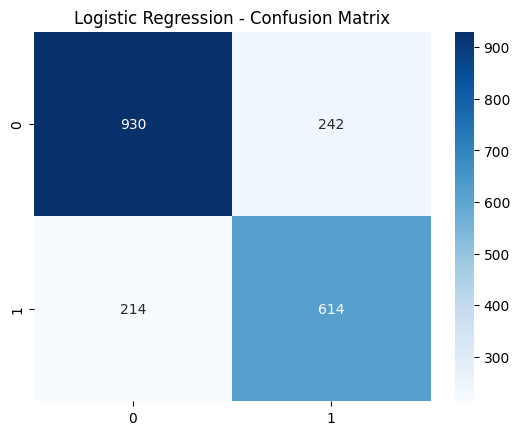


Random Forest Results:
Accuracy: 0.795
              precision    recall  f1-score   support

           0       0.82      0.84      0.83      1172
           1       0.76      0.73      0.75       828

    accuracy                           0.80      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.79      0.80      0.79      2000



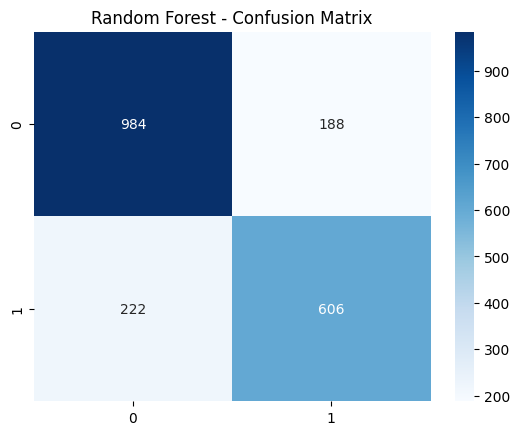

In [186]:
# Step 4: Model Building and Evaluation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Separate features and target
X = data.drop('PlacementStatus', axis=1)  
y = data['PlacementStatus']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train models
log_model = LogisticRegression()
rf_model = RandomForestClassifier(random_state=42)

log_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# Evaluate models
for name, model in [('Logistic Regression', log_model), ('Random Forest', rf_model)]:
    y_pred = model.predict(X_test)
    print(f"\n{name} Results:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.show()


In [187]:
import joblib
joblib.dump(rf_model, 'placement_model.pkl')
print("Model saved successfully as placement_model.pkl")

Model saved successfully as placement_model.pkl


In [188]:
import shutil

# Move the model file from the working directory to the output directory
shutil.move('placement_model.pkl', '/kaggle/working/placement_model.pkl')

# Verify it exists there
import os
print("Files in /kaggle/working:", os.listdir('/kaggle/working'))


Files in /kaggle/working: ['placement_model.pkl', '.virtual_documents']
